In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from warnings import filterwarnings
from types import SimpleNamespace as sn
from yaml import load, FullLoader
from psycopg2 import connect

In [14]:
import os

os.chdir(os.path.expanduser("~/classifier/src"))

In [15]:
from astrogeo.filter import Filter

In [16]:
# filterwarnings('ignore')
# with open('config/config.yaml') as f:
# 	config = sn(**load(f, Loader=FullLoader))
# 	config_db, path = sn(**config.db), config.fits_path

# cnx = connect(
#     host=config_db.host, dbname=config_db.dbname,
#     user=config_db.user, password=config_db.psswd
# )
# print('Successfully connected to database')
# maps = pd.read_sql('select * from maps24;', con=cnx)
# print('Successfully extracted data from database')
# print('Filtering data...')
# Filter(maps)
# print('Done')
# maps.to_csv('filtered_db.csv')

In [17]:
def preprocess(maps) -> np.array:
    pixel_size = maps['pixel_size_y'].to_numpy().T
    b_maj = maps['b_maj'].to_numpy().T * 3.6e6 / pixel_size
    b_min = maps['b_min'].to_numpy().T * 3.6e6 / pixel_size
    b_pa = maps['b_pa'].to_numpy().T

    return np.stack([b_maj, b_min, b_pa])

In [20]:
def draw_b_maj_dist(X) -> None:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.subplots(1, 1)
    ax.set_title('Beam MAJ distribution')
    ax.hist(X[np.where(X < 500)], bins=1000)
    ax.set_xlabel('B_MAJ [pixels]')
    ax.set_ylabel('Number')
    ax.set_xlim(0, 100)
    plt.show()

In [24]:
Maps = pd.read_csv('notebooks/filtered_db.csv')
Maps = Maps.drop(['Unnamed: 0'], axis=1)
dec = [int(name[-4:-2]) for name in Maps.object_name]
Maps['Dec'] = dec

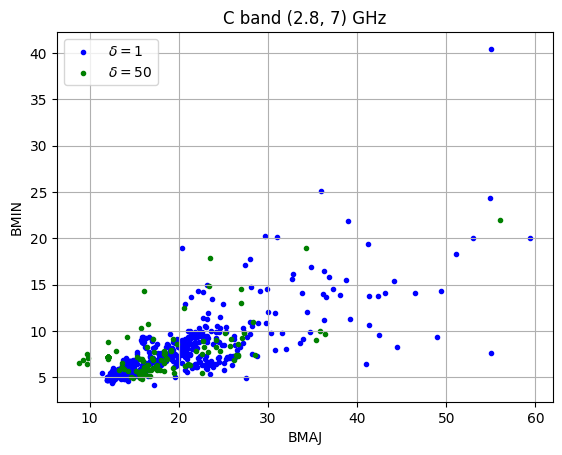

In [25]:
maps = Maps[(2.8 <= Maps.freq * 1e-9) & (Maps.freq * 1e-9 <= 7)] # C band
maps1, maps2 = maps[maps.Dec == 1], maps[maps.Dec == 50]
x, y = preprocess(maps1), preprocess(maps2)

fig = plt.figure()
ax = fig.subplots(1, 1)
ax.scatter(x[0], x[1], color='blue', marker='.', label=r'$\delta = 1$')
ax.scatter(y[0], y[1], color='green', marker='.', label=r'$\delta = 50$')
ax.set_xlabel('BMAJ')
ax.set_ylabel('BMIN')
ax.set_title('C band (2.8, 7) GHz')
plt.grid(True)
plt.legend()
plt.show()

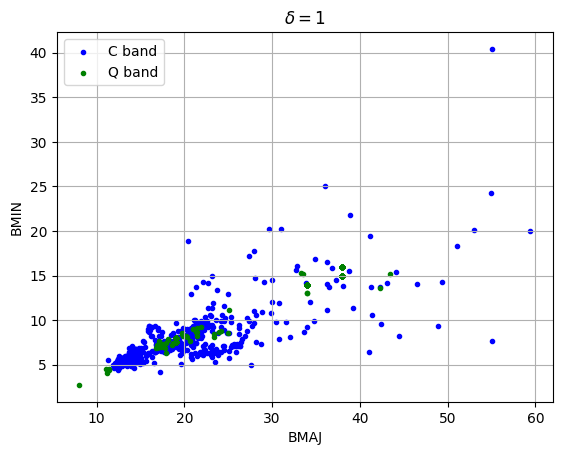

In [26]:
maps = Maps[Maps.Dec == 1]
maps1 = maps[(2.8 <= maps.freq * 1e-9) & (maps.freq * 1e-9 <= 7)] # C band
maps2 = maps[(26 <= maps.freq * 1e-9) & (maps.freq * 1e-9 <= 50)] # Q band
x, y = preprocess(maps1), preprocess(maps2)

fig = plt.figure()
ax = fig.subplots(1, 1)
ax.scatter(x[0], x[1], color='blue', marker='.', label='C band')
ax.scatter(y[0], y[1], color='green', marker='.', label='Q band')
ax.set_xlabel('BMAJ')
ax.set_ylabel('BMIN')
ax.set_title(r'$\delta = 1$')
plt.grid(True)
plt.legend()
plt.show()

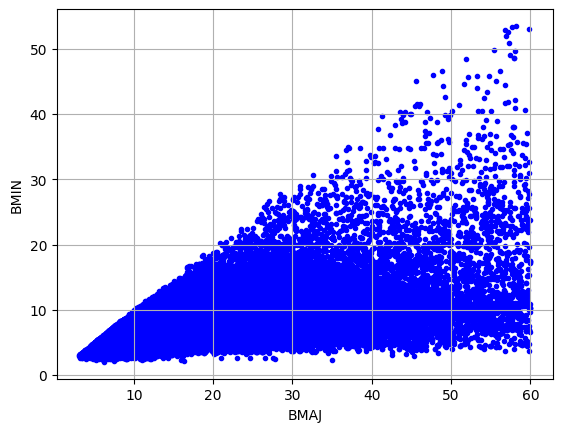

In [27]:
x = preprocess(Maps)

fig = plt.figure()
ax = fig.subplots(1, 1)
ax.scatter(x[0], x[1], color='blue', marker='.')
ax.set_xlabel('BMAJ')
ax.set_ylabel('BMIN')
plt.grid(True)
plt.show()

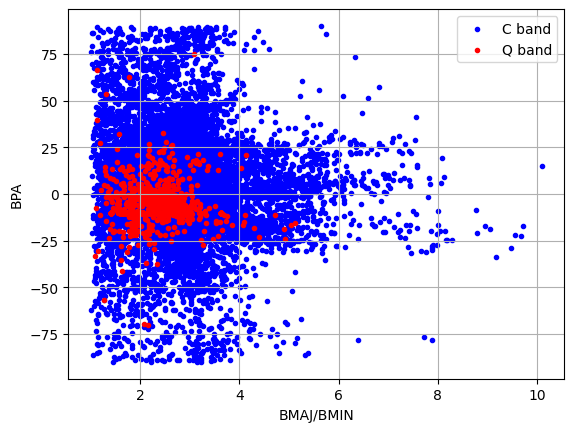

In [28]:
maps1 = Maps[(2.8 <= Maps.freq * 1e-9) & (Maps.freq * 1e-9 <= 7)] # C band
maps2 = Maps[(26 <= Maps.freq * 1e-9) & (Maps.freq * 1e-9 <= 50)] # Q band

x = preprocess(maps1)
y = preprocess(maps2)
fig = plt.figure()
ax = fig.subplots(1, 1)
ax.scatter(x[0]/x[1], x[2], color='blue', marker='.', label='C band')
ax.scatter(y[0]/y[1], y[2], color='red', marker='.', label='Q band')
ax.set_xlabel('BMAJ/BMIN')
ax.set_ylabel('BPA')
ax.grid(True)
plt.legend()
plt.show()

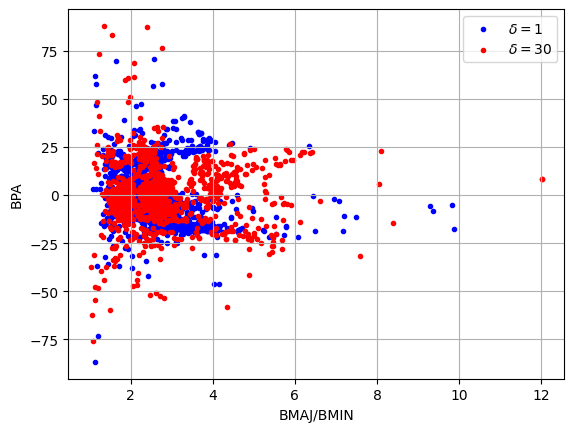

In [29]:
maps1 = Maps[Maps.Dec == 1] # declination = 1
maps2 = Maps[Maps.Dec == 30] # declination = 30

x = preprocess(maps1)
y = preprocess(maps2)
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.scatter(x[0]/x[1], x[2], color='blue', marker='.', label=r'$\delta = 1$')
ax.scatter(y[0]/y[1], y[2], color='red', marker='.', label=r'$\delta = 30$')
ax.set_xlabel('BMAJ/BMIN')
ax.set_ylabel('BPA')
ax.grid(True)
plt.legend()
plt.show()